# 🌿 Weed Crop Classification using Deep Learning
### Models: MobileNetV1 · MobileNetV2 · EfficientNetB0
### Dataset: V2 Plant Seedlings Dataset (12 classes)



## Step 1 — Install & Import

In [2]:
!pip install tensorflow scikit-learn matplotlib seaborn numpy -q

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNet, MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.16.2
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2 

In [4]:
import os

SOURCE_DIR = "/Users/srisabari/Desktop/Plant_weed_detection/weed_dataset"

classes = sorted([d for d in os.listdir(SOURCE_DIR)
                  if os.path.isdir(os.path.join(SOURCE_DIR, d))])

print(f'Found {len(classes)} classes:')
for c in classes:
    count = len(os.listdir(os.path.join(SOURCE_DIR, c)))
    print(f'  {c}: {count} images')

Found 12 classes:
  Black-grass: 309 images
  Charlock: 452 images
  Cleavers: 335 images
  Common Chickweed: 713 images
  Common wheat: 253 images
  Fat Hen: 538 images
  Loose Silky-bent: 762 images
  Maize: 257 images
  Scentless Mayweed: 607 images
  Shepherd’s Purse: 274 images
  Small-flowered Cranesbill: 576 images
  Sugar beet: 463 images


## Step 3 — Auto Split Dataset (70% Train / 20% Val / 10% Test)

In [6]:
import os
import shutil
import random

# ====== PATHS ======
SOURCE_DIR = "/Users/srisabari/Desktop/Plant_weed_detection/weed_dataset"

BASE_DIR = "/Users/srisabari/Desktop/Plant_weed_detection"
SPLIT_DIR = os.path.join(BASE_DIR, "dataset_split")

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR   = os.path.join(SPLIT_DIR, "val")
TEST_DIR  = os.path.join(SPLIT_DIR, "test")

# ====== RATIOS ======
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.20
# remaining = 0.10 (test)

# ====== SAFETY CHECK ======
if not os.path.exists(SOURCE_DIR):
    raise Exception(f"Source directory not found: {SOURCE_DIR}")

# ====== CLEAR OLD SPLIT ======
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# ====== GET CLASSES ======
classes = sorted([
    d for d in os.listdir(SOURCE_DIR)
    if os.path.isdir(os.path.join(SOURCE_DIR, d))
])

print(f"Found {len(classes)} classes\n")

total_copied = 0

# ====== SPLITTING ======
for cls in classes:
    cls_src = os.path.join(SOURCE_DIR, cls)

    images = [
        f for f in os.listdir(cls_src)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random.shuffle(images)

    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        TRAIN_DIR: images[:n_train],
        VAL_DIR:   images[n_train:n_train + n_val],
        TEST_DIR:  images[n_train + n_val:]
    }

    for split_dir, split_images in splits.items():
        dest = os.path.join(split_dir, cls)
        os.makedirs(dest, exist_ok=True)

        for img in split_images:
            src_path  = os.path.join(cls_src, img)
            dest_path = os.path.join(dest, img)

            shutil.copy(src_path, dest_path)

        total_copied += len(split_images)

    print(f"{cls:<25} total={n:>4}  train={n_train:>3}  val={n_val:>3}  test={n - n_train - n_val:>3}")

# ====== DONE ======
print(f"\nTotal images copied: {total_copied}")
print("✅ Dataset split complete!")

Found 12 classes

Black-grass               total= 309  train=216  val= 61  test= 32
Charlock                  total= 452  train=316  val= 90  test= 46
Cleavers                  total= 335  train=234  val= 67  test= 34
Common Chickweed          total= 713  train=499  val=142  test= 72
Common wheat              total= 253  train=177  val= 50  test= 26
Fat Hen                   total= 538  train=376  val=107  test= 55
Loose Silky-bent          total= 762  train=533  val=152  test= 77
Maize                     total= 257  train=179  val= 51  test= 27
Scentless Mayweed         total= 607  train=424  val=121  test= 62
Shepherd’s Purse          total= 274  train=191  val= 54  test= 29
Small-flowered Cranesbill total= 576  train=403  val=115  test= 58
Sugar beet                total= 463  train=324  val= 92  test= 47

Total images copied: 5539
✅ Dataset split complete!


## Step 4 — Config

In [7]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32        # reduce to 16 if you get memory errors
EPOCHS      = 30
NUM_CLASSES = len(classes)
CLASSES     = classes   # auto-detected from folder names

print(f'Classes ({NUM_CLASSES}): {CLASSES}')
print(f'Image size: {IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs:     {EPOCHS}')

Classes (12): ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherd’s Purse', 'Small-flowered Cranesbill', 'Sugar beet']
Image size: (224, 224)
Batch size: 32
Epochs:     30


## Step 5 — Data Augmentation & Generators

In [8]:
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenetv1_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenetv2_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# ── MobileNetV1 generators (expects [0,1] after rescale=1/255) ──
v1_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
v1_val_datagen = ImageDataGenerator(rescale=1./255)

v1_train_gen = v1_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
v1_val_gen = v1_val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
v1_test_gen = v1_val_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# ── MobileNetV2 generators (expects [-1,1] via mobilenetv2_preprocess) ──
v2_train_datagen = ImageDataGenerator(
    preprocessing_function=mobilenetv2_preprocess,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
v2_val_datagen = ImageDataGenerator(preprocessing_function=mobilenetv2_preprocess)

v2_train_gen = v2_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
v2_val_gen = v2_val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
v2_test_gen = v2_val_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# ── EfficientNetB0 generators (expects [0,255] raw pixels; built-in preprocess) ──
eff_train_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
eff_val_datagen = ImageDataGenerator(preprocessing_function=efficientnet_preprocess)

eff_train_gen = eff_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
eff_val_gen = eff_val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
eff_test_gen = eff_val_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Use v1 gen as default for visualization (rescaled [0,1] looks correct)
train_gen = v1_train_gen

print(f'Train samples : {v1_train_gen.samples}')
print(f'Val samples   : {v1_val_gen.samples}')
print(f'Test samples  : {v1_test_gen.samples}')
print('✅ All model-specific generators created with correct preprocessing')

Found 3872 images belonging to 12 classes.
Found 1102 images belonging to 12 classes.
Found 565 images belonging to 12 classes.
Found 3872 images belonging to 12 classes.
Found 1102 images belonging to 12 classes.
Found 565 images belonging to 12 classes.
Found 3872 images belonging to 12 classes.
Found 1102 images belonging to 12 classes.
Found 565 images belonging to 12 classes.
Train samples : 3872
Val samples   : 1102
Test samples  : 565
✅ All model-specific generators created with correct preprocessing


## Step 6 — Visualize Sample Images

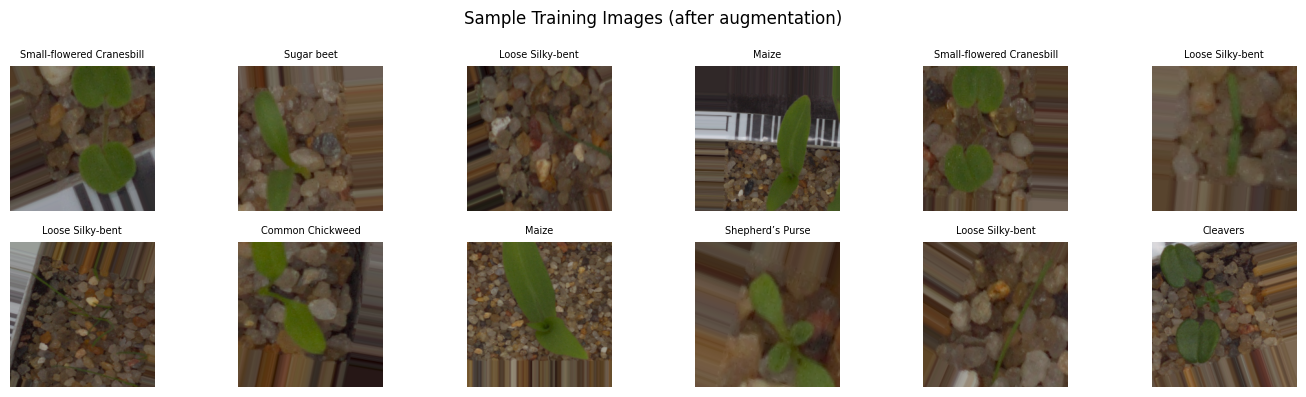

In [9]:
images, labels = next(train_gen)
class_names = list(train_gen.class_indices.keys())

plt.figure(figsize=(14, 4))
for i in range(12):
    plt.subplot(2, 6, i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])], fontsize=7)
    plt.axis('off')
plt.suptitle('Sample Training Images (after augmentation)', fontsize=12)
plt.tight_layout()
plt.show()

## Step 7 — Model Builder & Callbacks

In [12]:
def build_model(base_model, model_name):
    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f'{model_name} built ✅  |  Total params: {model.count_params():,}')
    return model

import os
os.makedirs('./checkpoints', exist_ok=True)

def get_callbacks(model_name):
    return [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=7,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            f'./checkpoints/{model_name}_best.h5',
            monitor='val_accuracy',
            save_best_only=True, verbose=0
        )
    ]

## Step 8 — Train MobileNetV1

In [13]:
base_v1  = MobileNet(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
model_v1 = build_model(base_v1, 'MobileNetV1')

print('\nTraining MobileNetV1...')
history_v1 = model_v1.fit(
    v1_train_gen,
    validation_data=v1_val_gen,
    epochs=EPOCHS,
    callbacks=get_callbacks('MobileNetV1')
)
print('MobileNetV1 done ✅')

MobileNetV1 built ✅  |  Total params: 3,365,708

Training MobileNetV1...
Epoch 1/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.4044 - loss: 2.4051

121/121 ━━━━━━━━━━━━━━━━━━━━ 35s 279ms/step - accuracy: 0.5176 - loss: 1.8246 - val_accuracy: 0.7495 - val_loss: 0.7603 - learning_rate: 0.0010
Epoch 2/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.6531 - loss: 1.2250

121/121 ━━━━━━━━━━━━━━━━━━━━ 33s 268ms/step - accuracy: 0.6684 - loss: 1.1544 - val_accuracy: 0.8212 - val_loss: 0.5637 - learning_rate: 0.0010
Epoch 3/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.6945 - loss: 1.0465

121/121 ━━━━━━━━━━━━━━━━━━━━ 33s 268ms/step - accuracy: 0.6999 - loss: 1.0181 - val_accuracy: 0.8249 - val_loss: 0.5974 - learning_rate: 0.0010
Epoch 4/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 33s 269ms/step - accuracy: 0.7260 - loss: 0.9312 - val_accuracy: 0.8240 - val_loss: 0.5960 - learning_rate: 0.0010
Epoch 5/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 33s 269ms/step - accuracy: 0.7301 - loss: 0.8981 - val_accuracy: 0.8249 - val_loss: 0.5030 - learning_rate: 0.0010
Epoch 6/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7381 - loss: 0.8476

121/121 ━━━━━━━━━━━━━━━━━━━━ 34s 277ms/step - accuracy: 0.7366 - loss: 0.8813 - val_accuracy: 0.8430 - val_loss: 0.5221 - learning_rate: 0.0010
Epoch 7/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 39s 324ms/step - accuracy: 0.7549 - loss: 0.7973 - val_accuracy: 0.8285 - val_loss: 0.5655 - learning_rate: 0.0010
Epoch 8/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7449 - loss: 0.7984
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


...

121/121 ━━━━━━━━━━━━━━━━━━━━ 45s 374ms/step - accuracy: 0.7701 - loss: 0.7439 - val_accuracy: 0.8548 - val_loss: 0.4817 - learning_rate: 5.0000e-04
Epoch 12/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.7825 - loss: 0.6785

121/121 ━━━━━━━━━━━━━━━━━━━━ 46s 377ms/step - accuracy: 0.7792 - loss: 0.6991 - val_accuracy: 0.8593 - val_loss: 0.4682 - learning_rate: 5.0000e-04
Epoch 13/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 45s 371ms/step - accuracy: 0.7740 - loss: 0.7047 - val_accuracy: 0.8575 - val_loss: 0.4492 - learning_rate: 5.0000e-04
Epoch 14/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 46s 380ms/step - accuracy: 0.7676 - loss: 0.7372 - val_accuracy: 0.8584 - val_loss: 0.4546 - learning_rate: 5.0000e-04
Epoch 15/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 48s 393ms/step - accuracy: 0.7632 - loss: 0.7176 - val_accuracy: 0.8593 - val_loss: 0.4342 - learning_rate: 5.0000e-04
Epoch 16/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 49s 404ms/step - accuracy: 0.7720 - loss: 0.7117 - val_accuracy: 0.8566 - val_loss: 0.4502 - learning_rate: 5.0000e-04
Epoch 17/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.7961 - loss: 0.6453

121/121 ━━━━━━━━━━━━━━━━━━━━ 49s 406ms/step - accuracy: 0.7843 - loss: 0.6770 - val_accuracy: 0.8612 - val_loss: 0.4408 - learning_rate: 5.0000e-04
Epoch 18/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.7916 - loss: 0.6819
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
121/121 ━━━━━━━━━━━━━━━━━━━━ 50s 410ms/step - accuracy: 0.7818 - loss: 0.6840 - val_accuracy: 0.8530 - val_loss: 0.4544 - learning_rate: 5.0000e-04
Epoch 19/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.7813 - loss: 0.6495

121/121 ━━━━━━━━━━━━━━━━━━━━ 59s 485ms/step - accuracy: 0.7787 - loss: 0.6702 - val_accuracy: 0.8657 - val_loss: 0.4535 - learning_rate: 2.5000e-04
Epoch 20/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 56s 463ms/step - accuracy: 0.7794 - loss: 0.6844 - val_accuracy: 0.8530 - val_loss: 0.4485 - learning_rate: 2.5000e-04
Epoch 21/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 50s 413ms/step - accuracy: 0.7869 - loss: 0.6642 - val_accuracy: 0.8639 - val_loss: 0.4247 - learning_rate: 2.5000e-04
Epoch 22/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 48s 392ms/step - accuracy: 0.7794 - loss: 0.6860 - val_accuracy: 0.8639 - val_loss: 0.4230 - learning_rate: 2.5000e-04
Epoch 23/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.7730 - loss: 0.7215

121/121 ━━━━━━━━━━━━━━━━━━━━ 47s 390ms/step - accuracy: 0.7789 - loss: 0.6853 - val_accuracy: 0.8675 - val_loss: 0.4184 - learning_rate: 2.5000e-04
Epoch 24/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 47s 386ms/step - accuracy: 0.7828 - loss: 0.6737 - val_accuracy: 0.8584 - val_loss: 0.4257 - learning_rate: 2.5000e-04
Epoch 25/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 47s 386ms/step - accuracy: 0.7776 - loss: 0.6952 - val_accuracy: 0.8657 - val_loss: 0.4341 - learning_rate: 2.5000e-04
Epoch 26/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.7869 - loss: 0.6586
Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
121/121 ━━━━━━━━━━━━━━━━━━━━ 49s 404ms/step - accuracy: 0.7833 - loss: 0.6722 - val_accuracy: 0.8621 - val_loss: 0.4342 - learning_rate: 2.5000e-04
Epoch 27/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 49s 406ms/step - accuracy: 0.7880 - loss: 0.6507 - val_accuracy: 0.8639 - val_loss: 0.4319 - learning_rate: 1.2500e-04
Epoch 28/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 50s 410ms/step - 

## Step 9 — Train MobileNetV2

In [14]:
from tensorflow.keras import Input

# MobileNetV2 built with correct [-1,1] preprocessing via its own generator
base_v2 = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
model_v2 = build_model(base_v2, 'MobileNetV2')

print('\nTraining MobileNetV2 (with correct [-1,1] preprocessing)...')
history_v2 = model_v2.fit(
    v2_train_gen,
    validation_data=v2_val_gen,
    epochs=EPOCHS,
    callbacks=get_callbacks('MobileNetV2')
)
print('MobileNetV2 done ✅')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
MobileNetV2 built ✅  |  Total params: 2,428,620

Training MobileNetV2 (with correct [-1,1] preprocessing)...
Epoch 1/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3643 - loss: 2.5969

121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 474ms/step - accuracy: 0.4633 - loss: 2.0928 - val_accuracy: 0.6661 - val_loss: 1.0065 - learning_rate: 0.0010
Epoch 2/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6048 - loss: 1.4833

121/121 ━━━━━━━━━━━━━━━━━━━━ 57s 468ms/step - accuracy: 0.6216 - loss: 1.4228 - val_accuracy: 0.7495 - val_loss: 0.8180 - learning_rate: 0.0010
Epoch 3/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.6285 - loss: 1.3498

121/121 ━━━━━━━━━━━━━━━━━━━━ 58s 478ms/step - accuracy: 0.6188 - loss: 1.3651 - val_accuracy: 0.7568 - val_loss: 0.7863 - learning_rate: 0.0010
Epoch 4/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.6570 - loss: 1.1821

121/121 ━━━━━━━━━━━━━━━━━━━━ 56s 462ms/step - accuracy: 0.6599 - loss: 1.1939 - val_accuracy: 0.7650 - val_loss: 0.7178 - learning_rate: 0.0010
Epoch 5/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.6681 - loss: 1.1425

...

121/121 ━━━━━━━━━━━━━━━━━━━━ 61s 499ms/step - accuracy: 0.7188 - loss: 0.8661 - val_accuracy: 0.8031 - val_loss: 0.5704 - learning_rate: 5.0000e-04
Epoch 22/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7254 - loss: 0.8684

121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 494ms/step - accuracy: 0.7249 - loss: 0.8673 - val_accuracy: 0.8122 - val_loss: 0.5623 - learning_rate: 5.0000e-04
Epoch 23/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 494ms/step - accuracy: 0.7319 - loss: 0.8536 - val_accuracy: 0.8094 - val_loss: 0.5427 - learning_rate: 5.0000e-04
Epoch 24/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.7330 - loss: 0.7942

121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 493ms/step - accuracy: 0.7309 - loss: 0.7973 - val_accuracy: 0.8158 - val_loss: 0.5290 - learning_rate: 5.0000e-04
Epoch 25/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.7213 - loss: 0.8245

121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 496ms/step - accuracy: 0.7296 - loss: 0.8195 - val_accuracy: 0.8212 - val_loss: 0.5462 - learning_rate: 5.0000e-04
Epoch 26/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 493ms/step - accuracy: 0.7376 - loss: 0.8129 - val_accuracy: 0.8040 - val_loss: 0.5751 - learning_rate: 5.0000e-04
Epoch 27/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.7219 - loss: 0.8200
Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
121/121 ━━━━━━━━━━━━━━━━━━━━ 61s 499ms/step - accuracy: 0.7120 - loss: 0.8658 - val_accuracy: 0.8076 - val_loss: 0.5430 - learning_rate: 5.0000e-04
Epoch 28/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 59s 482ms/step - accuracy: 0.7423 - loss: 0.7930 - val_accuracy: 0.8103 - val_loss: 0.5473 - learning_rate: 2.5000e-04
Epoch 29/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.7310 - loss: 0.8097

121/121 ━━━━━━━━━━━━━━━━━━━━ 61s 505ms/step - accuracy: 0.7322 - loss: 0.8002 - val_accuracy: 0.8221 - val_loss: 0.5592 - learning_rate: 2.5000e-04
Epoch 30/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.7374 - loss: 0.7778
Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
121/121 ━━━━━━━━━━━━━━━━━━━━ 61s 499ms/step - accuracy: 0.7330 - loss: 0.7874 - val_accuracy: 0.8049 - val_loss: 0.5347 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 29.
MobileNetV2 done ✅


## Step 10 — Train EfficientNetB0

In [ ]:
from tensorflow.keras import Input

# EfficientNetB0 — uses eff_train_gen / eff_val_gen defined in Step 5
inputs = Input(shape=(*IMG_SIZE, 3))
x = EfficientNetB0(include_top=False, weights='imagenet')(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_eff = Model(inputs=inputs, outputs=output, name='EfficientNetB0')
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'EfficientNetB0 built ✅  |  Total params: {model_eff.count_params():,}')

print('\nTraining EfficientNetB0...')
history_eff = model_eff.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=EPOCHS,
    callbacks=get_callbacks('EfficientNetB0')
)
print('EfficientNetB0 done ✅')

## Step 11 — Fine-tuning All Models

In [17]:
## Step 11 — Fine-tune All Models (fair comparison)

def fine_tune_model(model, model_name, train_gen, val_gen, ft_epochs=10, lr=1e-5):
    print(f'\nFine-tuning {model_name}...')
    for layer in model.layers:
        layer.trainable = True
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=ft_epochs,
        callbacks=get_callbacks(f'{model_name}_ft')
    )
    print(f'{model_name} fine-tune done ✅')
    return history

ft_history_v1  = fine_tune_model(model_v1,  'MobileNetV1',   v1_train_gen,  v1_val_gen)
ft_history_v2  = fine_tune_model(model_v2,  'MobileNetV2',   v2_train_gen,  v2_val_gen)
ft_history_eff = fine_tune_model(model_eff, 'EfficientNetB0', eff_train_gen, eff_val_gen)


Fine-tuning MobileNetV1...
Epoch 1/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8014 - loss: 0.6155 - val_accuracy: 0.8512 - val_loss: 0.4719 - learning_rate: 1.0000e-05
Epoch 2/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.8053 - loss: 0.5990 - val_accuracy: 0.8512 - val_loss: 0.4655 - learning_rate: 1.0000e-05
Epoch 3/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8177 - loss: 0.5818 - val_accuracy: 0.8566 - val_loss: 0.4480 - learning_rate: 1.0000e-05
Epoch 4/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.8107 - loss: 0.5619 - val_accuracy: 0.8548 - val_loss: 0.4414 - learning_rate: 1.0000e-05
Epoch 5/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.8215 - loss: 0.5466 - val_accuracy: 0.8621 - val_loss: 0.4317 - learning_rate: 1.0000e-05
Epoch 6/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.8334 - loss: 0.5150 - val_accuracy: 0.8621 - val_loss: 0.4283 - learning_rate: 1.0000e-05
Epoch 7/10
121/121 ━━━━━━━━━━━

In [18]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

results = {}

def evaluate_model(model, model_name, gen):
    print(f'\n{"-"*45}')
    print(f'  {model_name}')
    print(f'{"-"*45}')

    gen.reset()
    loss, acc = model.evaluate(gen, verbose=0)
    print(f'  Test Accuracy: {acc*100:.2f}%')
    print(f'  Test Loss:     {loss:.4f}')

    gen.reset()
    preds  = model.predict(gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = gen.classes

    print('\n  Classification Report:')
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    results[model_name] = {
        'loss': loss, 'accuracy': acc,
        'y_true': y_true, 'y_pred': y_pred,
        'params': model.count_params()
    }

evaluate_model(model_v1,  'MobileNetV1',    v1_test_gen)
evaluate_model(model_v2,  'MobileNetV2',    v2_test_gen)
evaluate_model(model_eff, 'EfficientNetB0', eff_test_gen)


---------------------------------------------
  MobileNetV1
---------------------------------------------
  Test Accuracy: 89.20%
  Test Loss:     0.2934

  Classification Report:
                           precision    recall  f1-score   support

              Black-grass       0.60      0.28      0.38        32
                 Charlock       1.00      1.00      1.00        46
                 Cleavers       0.94      0.94      0.94        34
         Common Chickweed       0.89      0.94      0.92        72
             Common wheat       0.92      0.85      0.88        26
                  Fat Hen       0.96      0.84      0.89        55
         Loose Silky-bent       0.73      0.94      0.82        77
                    Maize       0.96      0.89      0.92        27
        Scentless Mayweed       0.95      0.89      0.92        62
         Shepherd’s Purse       0.90      0.93      0.92        29
Small-flowered Cranesbill       1.00      1.00      1.00        58
              

In [15]:
model_v1 = tf.keras.models.load_model('./checkpoints/MobileNetV1_ft_best.h5')
model_v2 = tf.keras.models.load_model('./checkpoints/MobileNetV2_ft_best.h5')
print("Fine-tuned models reloaded ✅")

Fine-tuned models reloaded ✅


## Step 12 — Evaluate All Models

In [16]:
CLASSES = sorted(v1_test_gen.class_indices.keys())
results = {}

def evaluate_model(model, model_name, gen):
    print(f'\n{"-"*45}')
    print(f'  {model_name}')
    print(f'{"-"*45}')

    gen.reset()
    loss, acc = model.evaluate(gen, verbose=0)
    print(f'  Test Accuracy: {acc*100:.2f}%')
    print(f'  Test Loss:     {loss:.4f}')

    gen.reset()
    preds  = model.predict(gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = gen.classes

    print('\n  Classification Report:')
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    results[model_name] = {
        'loss': loss, 'accuracy': acc,
        'y_true': y_true, 'y_pred': y_pred,
        'params': model.count_params()
    }

# Each model evaluated with its correct preprocessing generator
evaluate_model(model_v1,  'MobileNetV1',    v1_test_gen)
evaluate_model(model_v2,  'MobileNetV2',    v2_test_gen)
evaluate_model(model_eff, 'EfficientNetB0', eff_test_gen)


---------------------------------------------
  MobileNetV1
---------------------------------------------
  Test Accuracy: 85.84%
  Test Loss:     0.3770

  Classification Report:
                           precision    recall  f1-score   support

              Black-grass       0.50      0.28      0.36        32
                 Charlock       0.94      1.00      0.97        46
                 Cleavers       0.94      0.88      0.91        34
         Common Chickweed       0.90      0.90      0.90        72
             Common wheat       0.78      0.69      0.73        26
                  Fat Hen       0.96      0.80      0.87        55
         Loose Silky-bent       0.70      0.90      0.79        77
                    Maize       0.96      0.89      0.92        27
        Scentless Mayweed       0.88      0.84      0.86        62
         Shepherd’s Purse       0.83      0.86      0.85        29
Small-flowered Cranesbill       0.98      1.00      0.99        58
              

## Step 13 — Confusion Matrices

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                annot_kws={'size': 7})
    ax.set_title(f'{name}\nAcc: {res["accuracy"]*100:.2f}%', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /content/confusion_matrices.png')

## Step 14 — Training Curves

In [ ]:
histories = [history_v1,  history_v2,  history_eff]
names     = ['MobileNetV1', 'MobileNetV2', 'EfficientNetB0']
colors    = ['#7c3aed', '#2563eb', '#dc2626']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for h, name, color in zip(histories, names, colors):
    axes[0].plot(h.history['val_accuracy'], label=name, color=color, linewidth=2)
    axes[1].plot(h.history['val_loss'],     label=name, color=color, linewidth=2)

axes[0].set_title('Validation Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Curves — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /content/training_curves.png')

## Step 15 — Final Comparison Table

In [ ]:
print('\n' + '='*70)
print(f'{"Model":<18} {"Test Accuracy":>15} {"Test Loss":>12} {"Params":>12}')
print('='*70)
for name, res in results.items():
    print(f'{name:<18} {res["accuracy"]*100:>14.2f}% {res["loss"]:>12.4f} {res["params"]:>12,}')
print('='*70)

best = max(results, key=lambda k: results[k]['accuracy'])
print(f'\n🏆 Best model: {best} ({results[best]["accuracy"]*100:.2f}%)')

## Step 16 — Save Everything to Google Drive

In [ ]:
SAVE_DIR = './weed_models'
os.makedirs(SAVE_DIR, exist_ok=True)

model_v1.save(os.path.join(SAVE_DIR, 'mobilenetv1.h5'))
model_v2.save(os.path.join(SAVE_DIR, 'mobilenetv2.h5'))
model_eff.save(os.path.join(SAVE_DIR, 'efficientnetb0.h5'))

import shutil
shutil.copy('/content/confusion_matrices.png', SAVE_DIR)
shutil.copy('/content/training_curves.png', SAVE_DIR)

print(f'All saved to {SAVE_DIR} ✅')

In [2]:
import os
ckpts = os.listdir('./checkpoints')
print(ckpts)

['MobileNetV1_ft_best.h5', 'MobileNetV2_ft_best.h5', 'MobileNetV2_best.h5', 'EfficientNetB0_best.h5', 'MobileNetV1_best.h5']


In [3]:
import tensorflow as tf

model_v1  = tf.keras.models.load_model('./checkpoints/MobileNetV1_best.h5')
model_v2  = tf.keras.models.load_model('./checkpoints/MobileNetV2_best.h5')
model_eff = tf.keras.models.load_model('./checkpoints/EfficientNetB0_best.h5')
print("All models reloaded ✅")

2026-04-09 19:04:38.419498: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-09 19:04:38.419523: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-09 19:04:38.419528: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-04-09 19:04:38.419552: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-09 19:04:38.419560: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


All models reloaded ✅


NameError: name 'fine_tune_model' is not defined

In [7]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenetv1_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenetv2_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

SPLIT_DIR = './dataset_split'   # ← change to your actual split path
TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# V1 generators
v1_train_gen = ImageDataGenerator(rescale=1./255, rotation_range=30, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)

v1_val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

v1_test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# V2 generators
v2_train_gen = ImageDataGenerator(preprocessing_function=mobilenetv2_preprocess, rotation_range=30,
    width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
    horizontal_flip=True, fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)

v2_val_gen = ImageDataGenerator(preprocessing_function=mobilenetv2_preprocess).flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

v2_test_gen = ImageDataGenerator(preprocessing_function=mobilenetv2_preprocess).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# EfficientNet generators
eff_train_gen = ImageDataGenerator(preprocessing_function=efficientnet_preprocess, rotation_range=30,
    width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
    horizontal_flip=True, fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)

eff_val_gen = ImageDataGenerator(preprocessing_function=efficientnet_preprocess).flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

eff_test_gen = ImageDataGenerator(preprocessing_function=efficientnet_preprocess).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

print("All generators ready ✅")

Found 3872 images belonging to 12 classes.
Found 1102 images belonging to 12 classes.
Found 565 images belonging to 12 classes.
Found 3872 images belonging to 12 classes.
Found 1102 images belonging to 12 classes.
Found 565 images belonging to 12 classes.
Found 3872 images belonging to 12 classes.
Found 1102 images belonging to 12 classes.
Found 565 images belonging to 12 classes.
All generators ready ✅


In [10]:
def get_callbacks(model_name):
    return [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=7,
            restore_best_weights=True, verbose=1
        )
        # ModelCheckpoint removed — causes Metal pickle error on M2
    ]

def fine_tune_model(model, model_name, train_gen, val_gen, ft_epochs=10, lr=1e-5):
    print(f'\nFine-tuning {model_name}...')
    for layer in model.layers:
        layer.trainable = True
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=ft_epochs,
        callbacks=get_callbacks(f'{model_name}_ft')
    )
    # Save manually after training instead
    model.save(f'./checkpoints/{model_name}_ft_best.keras')
    print(f'{model_name} fine-tune done ✅')
    return history

ft_history_eff = fine_tune_model(model_eff, 'EfficientNetB0', eff_train_gen, eff_val_gen)


Fine-tuning EfficientNetB0...
Epoch 1/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.9512 - loss: 0.1418 - val_accuracy: 0.9011 - val_loss: 0.3484 - learning_rate: 1.0000e-05
Epoch 2/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9551 - loss: 0.1387 - val_accuracy: 0.9456 - val_loss: 0.1736 - learning_rate: 1.0000e-05
Epoch 3/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.9558 - loss: 0.1244 - val_accuracy: 0.9501 - val_loss: 0.1546 - learning_rate: 1.0000e-05
Epoch 4/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.9540 - loss: 0.1342 - val_accuracy: 0.9528 - val_loss: 0.1504 - learning_rate: 1.0000e-05
Epoch 5/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.9538 - loss: 0.1292 - val_accuracy: 0.9537 - val_loss: 0.1510 - learning_rate: 1.0000e-05
Epoch 6/10
121/121 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.9514 - loss: 0.1393 - val_accuracy: 0.9510 - val_loss: 0.1490 - learning_rate: 1.0000e-05
Epoch 7/10
121/121 ━━━━━━━━